MG-MIX: AUC=0.8942 ACC=0.7783
MG-MP: AUC=0.8736 ACC=0.7590
MT-Net: AUC=0.8475 ACC=0.7651
MS-Net: AUC=0.7826 ACC=0.7120


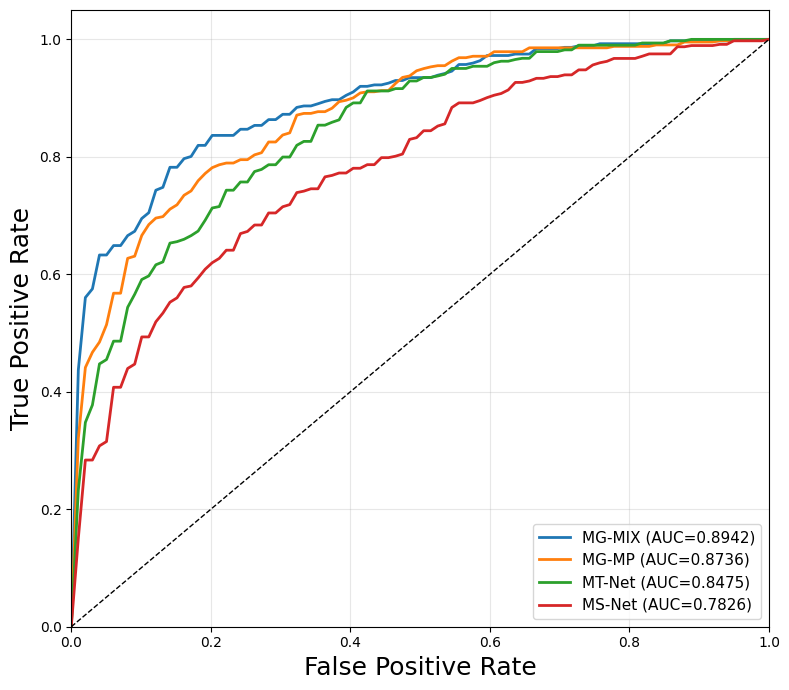


5-Fold Mean Performance

 Model    AUC  Accuracy     F1  Sensitivity  Specificity    PPV    NPV
MG-MIX 0.8942    0.7783 0.7786       0.7699       0.7860 0.8390 0.7684
 MG-MP 0.8736    0.7590 0.7624       0.7318       0.7944 0.8432 0.7429
MT-Net 0.8475    0.7651 0.7829       0.7848       0.7275 0.7937 0.7465
MS-Net 0.7826    0.7120 0.7060       0.6360       0.7878 0.8020 0.6339

ROC figure saved as: /data/Li/RocCurves/Mean_ROC_sh_5Fold.png
Results saved as: Mean_ROC_Results.csv


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    f1_score
)


csv_files = [
    {"path": r"/data/Li/Result/MT_MIX_shcbam_results/all_predictions.csv", "name": "MG-MIX"},
    {"path": r"/data/Li/Result/MT_MP_shcbam_results/all_predictions.csv", "name": "MG-MP"},
    {"path": r"/data/Li/Result/MT_Net_shcbam_results/all_predictions.csv", "name": "MT-Net"},
    {"path": r"/data/Li/Result/MS_Net_sh_results/all_predictions.csv", "name": "MS-Net"},
    #{"path": r"/data/Li/Result/baseline_wo_results/all_predictions.csv", "name": "Baseline"}
]

output_plot = r"/data/Li/RocCurves/Mean_ROC_sh_5Fold.png"
def calc_metrics(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(y_true,y_pred,labels=[0, 1]).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    f1 = f1_score(y_true,y_pred,zero_division=0)

    return {"ACC": acc,"F1": f1,"Sensitivity": sens,"Specificity": spec,"PPV": ppv,"NPV": npv}

def compute_mean_roc(df):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    fold_metrics = []
    folds = sorted(df["fold"].unique())
    for fold in folds:

        fold_df = df[df["fold"] == fold]

        y_true = fold_df["true_label"].values
        y_score = fold_df["pred_prob"].values
        if len(np.unique(y_true)) < 2:
            continue

        y_pred = (y_score >= 0.5).astype(int)

        metrics = calc_metrics(y_true,y_pred)
        fpr, tpr, _ = roc_curve(y_true,y_score)
        fold_auc = auc(fpr,tpr)

        metrics["AUC"] = fold_auc

        fold_metrics.append(metrics)
        interp_tpr = np.interp(mean_fpr,fpr,tpr)
        interp_tpr[0] = 0

        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs,axis=0)
    mean_tpr[-1] = 1

    return {
        "fpr": mean_fpr,
        "tpr": mean_tpr,
        "AUC": np.mean([m["AUC"] for m in fold_metrics]),
        "Accuracy": np.mean([m["ACC"] for m in fold_metrics]),
        "F1": np.mean([m["F1"] for m in fold_metrics]),
        "Sensitivity": np.mean([m["Sensitivity"] for m in fold_metrics]),
        "Specificity": np.mean([m["Specificity"] for m in fold_metrics]),
        "PPV": np.mean([m["PPV"] for m in fold_metrics]),
        "NPV": np.mean([m["NPV"] for m in fold_metrics]),
    }


plt.figure(figsize=(8, 7))
results = []
for item in csv_files:
    path = item["path"]
    name = item["name"]
    try:
        df = pd.read_csv(path)
        df = df.dropna(
            subset=["fold", "true_label", "pred_prob"]
        )
        metrics = compute_mean_roc(df)
        plt.plot(
            metrics["fpr"],
            metrics["tpr"],
            lw=2,
            label=f"{name} (AUC={metrics['AUC']:.4f})"
        )
        results.append({
            "Model": name,
            "AUC": metrics["AUC"],
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "Sensitivity": metrics["Sensitivity"],
            "Specificity": metrics["Specificity"],
            "PPV": metrics["PPV"],
            "NPV": metrics["NPV"]
        })
        print(
            f"{name}: "
            f"AUC={metrics['AUC']:.4f} "
            f"ACC={metrics['Accuracy']:.4f}"
        )
    except Exception as e:
        print(
            f"{name}: ERROR -> {e}"
        )

plt.plot([0, 1],[0, 1],'k--',lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate",fontsize=18)
plt.ylabel("True Positive Rate",fontsize=18)

plt.legend(loc="lower right",fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_plot,dpi=300,bbox_inches="tight")
plt.show()


results_df = pd.DataFrame(results)

print("\n==============================")
print("5-Fold Mean Performance")
print("==============================\n")
print(
    results_df.round(4).to_string(index=False)
)

results_df.to_csv(
    "Mean_ROC_Results.csv",
    index=False
)

print(f"\nROC figure saved as: {output_plot}")
print("Results saved as: Mean_ROC_Results.csv")

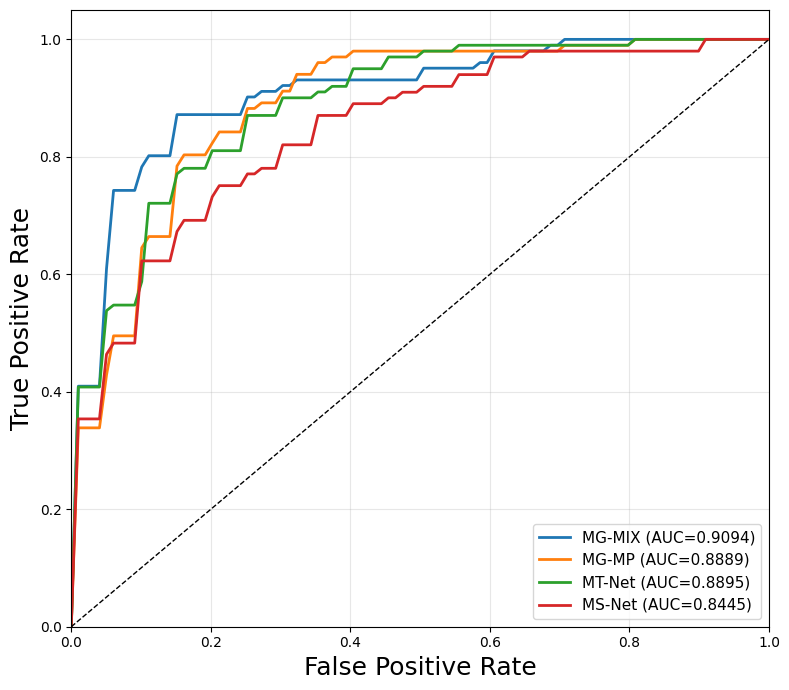


Patient-level 5-Fold Results

 Model    AUC  Accuracy     F1  Sensitivity  Specificity    PPV    NPV
MG-MIX 0.9094     0.800 0.7727       0.7814       0.8174 0.8487 0.8300
 MG-MP 0.8889     0.760 0.7462       0.7400       0.7737 0.8219 0.7985
MT-Net 0.8895     0.790 0.7935       0.8300       0.7458 0.7771 0.8458
MS-Net 0.8445     0.735 0.7280       0.6929       0.7789 0.7937 0.7138

Saved ROC: /data/Li/RocCurves/Mean_ROC_sh_5Fold_patient.png
Saved metrics: Patient_Level_Results.csv


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve,auc,confusion_matrix,f1_score)
output_plot_patient=r"/data/Li/RocCurves/Mean_ROC_sh_5Fold_patient.png"

def patient_level_average(df):

    patient_df = (
        df.groupby(
            ["fold", "patient_id"],
            as_index=False
        )
        .agg({
            "true_label": "first",
            "pred_prob": "mean"
        })
    )

    return patient_df



def calc_metrics(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0,1]
    ).ravel()

    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = f1_score(y_true,y_pred,zero_division=0)

    return {
        "ACC": acc,
        "F1": f1,
        "Sensitivity": sens,
        "Specificity": spec,
        "PPV": ppv,
        "NPV": npv
    }


def compute_mean_patient_roc(df):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    fold_metrics = []
    folds = sorted(df["fold"].unique())
    for fold in folds:
        fold_df = df[df["fold"] == fold]
        y_true = fold_df["true_label"].values
        y_score = fold_df["pred_prob"].values
        if len(np.unique(y_true)) < 2:
            continue
        y_pred = (y_score >= 0.5).astype(int)
        metrics = calc_metrics(y_true,y_pred)

        fpr, tpr, _ = roc_curve(y_true,y_score)
        fold_auc = auc(fpr,tpr)

        metrics["AUC"] = fold_auc

        fold_metrics.append(metrics)
        interp_tpr = np.interp(mean_fpr,fpr,tpr)
        interp_tpr[0] = 0
        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs,axis=0)
    mean_tpr[-1] = 1

    return {
        "fpr": mean_fpr,
        "tpr": mean_tpr,
        "AUC": np.mean([m["AUC"] for m in fold_metrics]),
        "Accuracy": np.mean([m["ACC"] for m in fold_metrics]),
        "F1": np.mean([m["F1"] for m in fold_metrics]),
        "Sensitivity": np.mean([m["Sensitivity"] for m in fold_metrics]),
        "Specificity": np.mean([m["Specificity"] for m in fold_metrics]),
        "PPV": np.mean([m["PPV"] for m in fold_metrics]),
        "NPV": np.mean([m["NPV"] for m in fold_metrics])
    }

# ==========================
# 绘图
# ==========================

plt.figure(figsize=(8,7))

results = []

for item in csv_files:

    try:
        df = pd.read_csv(item["path"])

        required_cols = ["fold","patient_id","true_label","pred_prob"]

        for col in required_cols:

            if col not in df.columns:
                raise ValueError(
                    f"Missing column: {col}"
                )

        df = df.dropna(
            subset=["fold","patient_id","true_label","pred_prob"])

        patient_df = patient_level_average(df)
        metrics = compute_mean_patient_roc(patient_df)

        plt.plot(metrics["fpr"],metrics["tpr"],lw=2,label=f"{item['name']} (AUC={metrics['AUC']:.4f})")

        results.append({
            "Model": item["name"],
            "AUC": metrics["AUC"],
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "Sensitivity": metrics["Sensitivity"],
            "Specificity": metrics["Specificity"],
            "PPV": metrics["PPV"],
            "NPV": metrics["NPV"]
        })

    except Exception as e:

        print(
            f"{item['name']} ERROR: {e}"
        )

# ==========================
# ROC Figure
# ==========================

plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate",fontsize=18)

plt.ylabel("True Positive Rate",fontsize=18)
plt.legend(loc="lower right",fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(output_plot_patient,dpi=300,bbox_inches="tight")
plt.show()


results_df = pd.DataFrame(results)

print("\n==============================")
print("Patient-level 5-Fold Results")
print("==============================\n")

print(
    results_df.round(4).to_string(index=False)
)

results_df.to_csv("Patient_Level_Results.csv",index=False)
print(
    f"\nSaved ROC: {output_plot_patient}"
)

print(
    "Saved metrics: Patient_Level_Results.csv"
)

In [1]:
from MT_MP import MTMP
from MT_Net import MTNet
from MT_MIX import MTMIX
from MS_Net import MSNet
from MT_MP_wo import MTMP_wo
from MT_Net_wo import MTNet_wo
from MT_MIX_wo import MTMIX_wo
from MS_Net_wo import MSNet_wo
from MT_MP_shcbam import MTMP_sh
from MT_Net_shcbam import MTNet_sh
from MT_MIX_shcbam import MTMIX_sh
from MS_Net_sh import MSNet_sh

from Baseline import BaselineResUNetClassifier
from Baseline_wo import BaselineResUNetClassifier_wo

[RISE-CORE Msg(13877:140504562818560:libvgpu.c:903)]: Initializing.....
[RISE-CORE Warn(13877:140504562818560:multiprocess_memory_limit.c:597)]: Kick dead proc 12335


In [3]:
import os
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_root = r"/data/Li/Result" 

#model_folders = ["MT_MIX_models","MT_MP_models","MT_Net_models","MS_Net_models"]
#model_folders = ["MT_MIX_wo_models","MT_MP_wo_models","MT_Net_wo_models","MS_Net_wo_models"]
model_folders = ["MT_MIX_shcbam_models","MT_MP_shcbam_models","MT_Net_shcbam_models","MS_Net_sh_models"]


image_paths = [
    r"/data/Li/10images/S0_1607485_2.png",
    r"/data/Li/10images/S1_1600638_4.png",
    #r"/data/Li/10images/S2_1623828_2.png",
    r"/data/Li/dataset/1/1623828/2.png",
    r"/data/Li/10images/S3_1456410_2.png",
    r"/data/Li/10images/S4_1628244_1.png",
    r"/data/Li/10images/S0_1629857_1.PNG",
    r"/data/Li/10images/S1_1366486_4.png",
    r"/data/Li/dataset/1/1489598/1.png",
    #r"/data/Li/10images/S2_1607249_3.PNG",
    r"/data/Li/10images/S3_1695231_3.PNG",
    r"/data/Li/10images/S4_1682852_3.PNG",

]

image_fold_map = {
    r"/data/Li/10images/S0_1607485_2.png":3,
    r"/data/Li/10images/S1_1600638_4.png":5,
    r"/data/Li/dataset/1/1623828/2.png":1,
    #r"/data/Li/10images/S2_1623828_2.png":2,
    r"/data/Li/10images/S3_1456410_2.png":4,
    r"/data/Li/10images/S4_1628244_1.png":1,
    r"/data/Li/10images/S0_1629857_1.PNG":4,
    r"/data/Li/10images/S1_1366486_4.png":4,
    r"/data/Li/dataset/1/1489598/1.png":1,
    #r"/data/Li/10images/S2_1607249_3.PNG":1,
    r"/data/Li/10images/S3_1695231_3.PNG":2,
    r"/data/Li/10images/S4_1682852_3.PNG":3,

}


import glob

def get_model_path(folder_name, fold_id):

    folder_path = os.path.join(model_root, folder_name)

    candidates = glob.glob(os.path.join(folder_path, "*.pth"))

    matches = []

    for f in candidates:

        fname = os.path.basename(f).lower()

        if f"fold{fold_id}" in fname:
            matches.append(f)

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{folder_name} can not find fold{fold_id} model"
        )
    return matches[0]

def load_model(folder_name, model_path):
    if folder_name == "MS_Net_models":
        model = MSNet(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_MP_models":
        model = MTMP(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_MIX_models":
        model = MTMIX(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_Net_models":
        model = MTNet(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MS_Net_wo_models":
        model = MSNet_wo(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_MP_wo_models":
        model = MTMP_wo(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_MIX_wo_models":
        model = MTMIX_wo(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_Net_wo_models":
        model = MTNet_wo(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MS_Net_sh_models":
        model = MSNet_sh(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_MP_shcbam_models":
        model = MTMP_sh(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_MIX_shcbam_models":
        model = MTMIX_sh(in_channels=1,bilinear=True,dropout=0.3).to(device)
    elif folder_name == "MT_Net_shcbam_models":
        model = MTNet_sh(in_channels=1,bilinear=True,dropout=0.3).to(device)
    else:
        raise ValueError(f"nomodel: {folder_name}")

    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model

def get_last_conv(model):
    last = None
    for m in model.modules():
        if isinstance(m, torch.nn.Conv2d):
            last = m
    return last

class GradCAM:

    def __init__(self, model, layer):
        self.model = model
        self.gradients = None
        self.activations = None

        layer.register_forward_hook(self.forward_hook)
        layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):

        self.model.zero_grad()

        out = self.model(x)
        cls_logits = out["cls_logits"]

        prob = torch.sigmoid(cls_logits).detach().cpu().item()

        cls_logits.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2,3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        contribution = self.gradients.abs().mean().item()

        return cam, prob, contribution

def fuse_cams_weighted(cam_list, contrib_list, h, w):

    resized = []

    for cam in cam_list:

        cam = cv2.resize(cam, (w, h))

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        resized.append(cam)

    contrib = np.array(contrib_list)

    contrib = contrib / (contrib.sum() + 1e-8)

    fused = np.zeros_like(resized[0])

    for c, w in zip(resized, contrib):
        fused += w * c

    fused = (fused - fused.min()) / (fused.max() - fused.min() + 1e-8)

    return fused, contrib

def preprocess(img_path):
    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    img = img.astype(np.float32)
    img = img / 255.0
    tensor = torch.tensor(img,dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    return img, tensor.to(device)

def overlay(img, cam):
    h, w = img.shape
    cam = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam),cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap,cv2.COLOR_BGR2RGB)
    img_rgb = np.stack([img, img, img],axis=-1)
    out = (0.5 * img_rgb +0.5 * (heatmap / 255.0))
    return np.clip(out, 0, 1)


for folder in model_folders:
    save_dir = os.path.join(os.getcwd(), "Figure")
    os.makedirs(save_dir, exist_ok=True)
    fig, axes = plt.subplots(2, 5, figsize=(25, 8.5))
    axes = axes.flatten()

    #fig.suptitle(folder, fontsize=16)

    for i, img_path in enumerate(image_paths):
        fold_id = image_fold_map[img_path]
        model_path = get_model_path(folder, fold_id)
        model = load_model(folder, model_path)
        img, tensor = preprocess(img_path)
        h, w = img.shape

        cam_x4_engine = GradCAM(model,model.stage4)
        cam_x5_engine = GradCAM(model,model.stage5)
        cam_u1_engine = GradCAM(model,model.up1)
        cam_x4, prob, g4 = cam_x4_engine(tensor)

        cam_x5, _, g5 = cam_x5_engine(tensor)

        cam_u1, _, gu = cam_u1_engine(tensor)

        cam, weights = fuse_cams_weighted([cam_x4, cam_x5, cam_u1],[g4, g5, gu],h,w)

        print(
            f"x4={weights[0]:.3f}, "
            f"x5={weights[1]:.3f}, "
            f"u1={weights[2]:.3f}"
        )  

        result = overlay(img,cam)

        ax = axes[i]
        ax.imshow(result)
        ax.axis("off")
        ax.set_title(f"P={prob:.3f}", fontsize=20)

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{folder}_GradCAM.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

print("Done.")

x4=0.660, x5=0.320, u1=0.021
x4=0.512, x5=0.437, u1=0.051
x4=0.521, x5=0.442, u1=0.037
x4=0.616, x5=0.345, u1=0.039
x4=0.519, x5=0.439, u1=0.041
x4=0.536, x5=0.411, u1=0.053
x4=0.525, x5=0.419, u1=0.056
x4=0.525, x5=0.436, u1=0.039
x4=0.648, x5=0.315, u1=0.037
x4=0.654, x5=0.324, u1=0.022
x4=0.766, x5=0.229, u1=0.006
x4=0.550, x5=0.397, u1=0.053
x4=0.699, x5=0.280, u1=0.021
x4=0.664, x5=0.298, u1=0.038
x4=0.669, x5=0.305, u1=0.026
x4=0.604, x5=0.342, u1=0.054
x4=0.593, x5=0.349, u1=0.057
x4=0.698, x5=0.282, u1=0.020
x4=0.565, x5=0.384, u1=0.051
x4=0.777, x5=0.217, u1=0.005
x4=0.484, x5=0.472, u1=0.044
x4=0.534, x5=0.394, u1=0.072
x4=0.664, x5=0.316, u1=0.019
x4=0.769, x5=0.211, u1=0.021
x4=0.635, x5=0.344, u1=0.022
x4=0.754, x5=0.224, u1=0.022
x4=0.749, x5=0.231, u1=0.020
x4=0.663, x5=0.316, u1=0.021
x4=0.645, x5=0.328, u1=0.027
x4=0.505, x5=0.464, u1=0.030
x4=0.656, x5=0.326, u1=0.018
x4=0.805, x5=0.184, u1=0.011
x4=0.731, x5=0.253, u1=0.016
x4=0.730, x5=0.253, u1=0.017
x4=0.685, x5=0

In [14]:
import os
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_root = r"/data/Li/Result"

model_folders = ["baseline_models","baseline_wo_models"]



def get_model_path(folder_name, fold_id):
    folder_path = os.path.join(model_root, folder_name)
    candidates = glob.glob(os.path.join(folder_path, "*.pth"))

    for f in candidates:
        if f"fold{fold_id}" in os.path.basename(f).lower():
            return f

    raise FileNotFoundError(f"{folder_name} cannot find fold{fold_id} model")


def load_model(folder_name, model_path):

    if folder_name == "baseline_models":
        model = BaselineResUNetClassifier(in_channels=1, bilinear=True, dropout=0.3)
    elif folder_name == "baseline_wo_models":
        model = BaselineResUNetClassifier_wo(in_channels=1, bilinear=True, dropout=0.3)
    else:
        raise ValueError(folder_name)

    ckpt = torch.load(model_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device)
    model.eval()

    return model


class GradCAM:
    def __init__(self, model, layer):
        self.model = model
        self.gradients = None
        self.activations = None

        layer.register_forward_hook(self.forward_hook)
        layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):

        self.model.zero_grad()

        out = self.model(x)
        cls_logits = out["cls_logits"]

        prob = torch.sigmoid(cls_logits).detach().cpu().item()

        cls_logits.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam).squeeze()
        cam = cam.detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, prob


def preprocess(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    img = img / 255.0
    tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0)

    return img, tensor.to(device)


def overlay(img, cam):
    h, w = img.shape
    cam = cv2.resize(cam, (w, h))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_rgb = np.stack([img, img, img], axis=-1)

    out = 0.5 * img_rgb + 0.5 * (heatmap / 255.0)

    return np.clip(out, 0, 1)

for folder in model_folders:

    fig, axes = plt.subplots(2, 5, figsize=(25, 8.5))
    axes = axes.flatten()

    for i, img_path in enumerate(image_paths):

        fold_id = image_fold_map[img_path]
        model_path = get_model_path(folder, fold_id)
        model = load_model(folder, model_path)
        img, tensor = preprocess(img_path)
        h, w = img.shape
        cam_engine = GradCAM(model, model.stage5)

        cam, prob = cam_engine(tensor)

        result = overlay(img, cam)

        ax = axes[i]
        ax.imshow(result)
        ax.axis("off")
        ax.set_title(f"P={prob:.3f}", fontsize=20)

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{folder}_GradCAM.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

print("Done.")

Done.
